In [ ]:
# ============================================================
# NACC ALZHEIMER — 5 MODEL RELEASE PIPELINE (PARTS 0–8)
# - Uses frozen clean dataset: nacc_clean_complete_case_AD01.csv
# - 50 seeds, stratified 80/20
# - Models: XGBoost, LogReg, Ridge, KNN, Linear SVM (SVM last)
# - Includes: accuracy barplot, top10 importance barplots,
#            canonical metrics + tests, calibration, redundancy + plots
# - Excludes: heatmaps
# - Saves EVERYTHING to: ~/Research/Alzheimer/5 model/run_YYYYMMDD_HHMMSS/
# ============================================================

import json
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from xgboost import XGBClassifier
from sklearn import svm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from statsmodels.stats.contingency_tables import mcnemar

sns.set(style="whitegrid")

# -----------------------------
# Pretty helpers
# -----------------------------
def print_header(title):
    print("\n" + "="*100)
    print(title)
    print("="*100)

def safe_div(a, b):
    return a / b if b != 0 else np.nan

def compute_classification_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    if cm.size != 4:
        return {"Sensitivity": np.nan, "Specificity": np.nan, "Precision": np.nan, "F1": np.nan}
    tn, fp, fn, tp = cm.ravel()
    sens = safe_div(tp, tp + fn)
    spec = safe_div(tn, tn + fp)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {"Sensitivity": float(sens), "Specificity": float(spec), "Precision": float(prec), "F1": float(f1)}

# -----------------------------
# DeLong (correlated ROC-AUC test)
# -----------------------------
def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1)
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T + 1
    return T2

def _fastDeLong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    pos = predictions_sorted_transposed[:, :m]
    neg = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)

    for r in range(k):
        tx[r, :] = _compute_midrank(pos[r, :])
        ty[r, :] = _compute_midrank(neg[r, :])
        tz[r, :] = _compute_midrank(predictions_sorted_transposed[r, :])

    aucs = tz[:, :m].sum(axis=1) / (m * n) - (m + 1.0) / (2.0 * n)
    v01 = (tx / n) - (tz[:, :m] / n)
    v10 = 1.0 - (ty / m) + (tz[:, m:] / m)

    sx = np.cov(v01)
    sy = np.cov(v10)
    s = sx / m + sy / n
    return aucs, s

def delong_roc_test(y_true, y_scores_a, y_scores_b):
    y_true = np.asarray(y_true).astype(int)
    order = np.argsort(-y_true)
    y_sorted = y_true[order]
    preds_sorted = np.vstack([np.asarray(y_scores_a)[order], np.asarray(y_scores_b)[order]])

    m = int(np.sum(y_sorted))
    aucs, cov = _fastDeLong(preds_sorted, m)
    diff = aucs[0] - aucs[1]
    var = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    if var <= 0:
        return np.nan, np.nan, float(aucs[0]), float(aucs[1])
    z = diff / np.sqrt(var)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return float(z), float(p), float(aucs[0]), float(aucs[1])

# -----------------------------
# McNemar
# -----------------------------
def mcnemar_test(y_true, y_pred_a, y_pred_b):
    y_true = np.asarray(y_true)
    y_pred_a = np.asarray(y_pred_a)
    y_pred_b = np.asarray(y_pred_b)

    both_correct = np.sum((y_pred_a == y_true) & (y_pred_b == y_true))
    a_correct_b_wrong = np.sum((y_pred_a == y_true) & (y_pred_b != y_true))
    a_wrong_b_correct = np.sum((y_pred_a != y_true) & (y_pred_b == y_true))
    both_wrong = np.sum((y_pred_a != y_true) & (y_pred_b != y_true))

    table = [[both_correct, a_correct_b_wrong],
             [a_wrong_b_correct, both_wrong]]
    res = mcnemar(table, exact=False, correction=True)
    return float(res.statistic), float(res.pvalue), table

# ============================================================
# PART 0) LOAD CLEAN FROZEN DATA + OUTPUT FOLDER
# ============================================================
print_header("PART 0) LOAD CLEAN FROZEN DATA + CREATE OUTPUT FOLDER")

BASE_DIR = Path.home() / "Research" / "Alzheimer"
DATA_PATH = BASE_DIR / "nacc_clean_complete_case_AD02.csv"   # <-- AD02
TARGET = "NACCALZD"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find dataset at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, low_memory=False)

# Keep definitive labels only
df = df[df[TARGET].isin([0, 1])].copy()
df[TARGET] = df[TARGET].astype(int)

# Drop leakage / ID / visit metadata (safe even if already absent in AD02)
DROP_COLS = [
    TARGET,

    # likely label-derived/leakage flags
    "ad_flag", "mci_flag", "dementia_flag",
    "DEMENTED", "NACCTMCI", "NORMCOG",

    # identifiers / visit timing / birth timing
    "NACCID", "NACCVNUM", "VISITYR", "VISITMO", "VISITDAY",
    "BIRTHYR", "BIRTHMO",

    # removed when forming AD02 (from your screenshot)
    "AMYLPET", "TAUPETAD", "FDGAD", "AMYLCSF", "CSFTAU",
    "NACCMMS", "NACCMOCA",
    "CDRSUM", "CDRGLOB",
]

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore")
X = X.select_dtypes(include=[np.number]).copy()
y = df[TARGET].copy()
feature_names = X.columns.tolist()

timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = BASE_DIR / "5 model" / f"run_{timestamp}"
(OUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)

print("✅ Loaded:", DATA_PATH)
print("Shape df:", df.shape)
print("Shape X :", X.shape)
print("Positive rate:", float(np.mean(y == 1)))
print("✅ Output folder:", OUT_DIR)

# Save manifest early
manifest0 = {
    "data_path": str(DATA_PATH),
    "out_dir": str(OUT_DIR),
    "n_rows": int(df.shape[0]),
    "n_features": int(X.shape[1]),
    "target": TARGET,
    "dropped_cols_present": [c for c in DROP_COLS if c in df.columns],
}
with open(OUT_DIR / "manifest_part0.json", "w") as f:
    json.dump(manifest0, f, indent=2)

# ============================================================
# MODELS (5 only; SVM last)
# ============================================================
def build_models(seed=0):
    return {
        "XGBoost": XGBClassifier(
            tree_method="hist",
            random_state=seed,
            n_estimators=300,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            n_jobs=-1
        ),
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=10000, random_state=seed))
        ]),
        "Ridge Classifier": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RidgeClassifier(random_state=seed))
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=5))
        ]),
        # SLOWEST LAST
        "SVM (Linear)": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", svm.SVC(kernel="linear", probability=True, random_state=seed))
        ]),
    }

MODEL_ORDER = list(build_models(0).keys())

# ============================================================
# PART 1) ACCURACY ACROSS 50 SEEDS (+ save canonical split)
# ============================================================
print_header("PART 1) ACCURACY ACROSS 50 SEEDS (80/20 stratified) — SVM LAST")

SEEDS = list(range(50))
canonical_seed = SEEDS[-1]

acc_seed = {m: [] for m in MODEL_ORDER}
X_train = X_test = y_train = y_test = None

pbar = tqdm(SEEDS, desc="Part 1: 50 seeds (accuracy)", leave=True)

for seed in pbar:
    Xt, Xv, yt, yv = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    models = build_models(seed)

    # run in batches: loop in fixed order (SVM last)
    for name in MODEL_ORDER:
        model = models[name]
        model.fit(Xt, yt)
        pred = model.predict(Xv)
        acc_seed[name].append(float(accuracy_score(yv, pred)))

    if seed == canonical_seed:
        X_train, X_test, y_train, y_test = Xt, Xv, yt, yv

seed_acc_df = pd.DataFrame(acc_seed)
seed_acc_path = OUT_DIR / "tables" / "seed_accuracies_5models.csv"
seed_acc_df.to_csv(seed_acc_path, index=False)
print("✅ Saved:", seed_acc_path)

# Accuracy summary
acc_summary = pd.DataFrame({
    "Model": MODEL_ORDER,
    "mean_acc": [seed_acc_df[m].mean() for m in MODEL_ORDER],
    "sd_acc":   [seed_acc_df[m].std(ddof=1) for m in MODEL_ORDER],
}).sort_values("mean_acc", ascending=False)
acc_summary_path = OUT_DIR / "tables" / "accuracy_summary_mean_sd_5models.csv"
acc_summary.to_csv(acc_summary_path, index=False)
print("✅ Saved:", acc_summary_path)

# ============================================================
# PART 2) ACCURACY BAR PLOT (5 models, colored bars)
# ============================================================
print_header("PART 2) ACCURACY BAR PLOT (5 models)")

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=acc_summary, x="Model", y="mean_acc", palette="tab10", ci=None)
# Add numeric labels above bars (mean accuracy)
for i, v in enumerate(acc_summary["mean_acc"].values):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=10)
ax.errorbar(
    x=np.arange(acc_summary.shape[0]),
    y=acc_summary["mean_acc"].values,
    yerr=acc_summary["sd_acc"].values,
    fmt="none",
    capsize=6,
    linewidth=2
)
ax.set_title("Accuracy Across 50 Seeds (Mean ± SD) — 5 Models")
ax.set_xlabel("")
ax.set_ylabel("Accuracy")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.tight_layout()

fig_acc = OUT_DIR / "figures" / "accuracy_bar_5models.png"
plt.savefig(fig_acc, dpi=300)
plt.close()
print("✅ Saved:", fig_acc)

# Paired t-tests (accuracy)
tt_rows = []
names = MODEL_ORDER
for i in range(len(names)):
    for j in range(i+1, len(names)):
        A, B = names[i], names[j]
        t, p = stats.ttest_rel(seed_acc_df[A], seed_acc_df[B])
        tt_rows.append({"A": A, "B": B, "t_stat": float(t), "p_value": float(p)})
tt_df = pd.DataFrame(tt_rows).sort_values("p_value")
tt_path = OUT_DIR / "tables" / "paired_ttests_accuracy_across_seeds_5models.csv"
tt_df.to_csv(tt_path, index=False)
print("✅ Saved:", tt_path)

# ============================================================
# PART 3) FEATURE IMPORTANCE ACROSS SEEDS (Top-10 + bar charts)
# ============================================================
print_header("PART 3) FEATURE IMPORTANCE ACROSS 50 SEEDS (Top-10 per model)")

feat_imp = {m: [] for m in MODEL_ORDER}
pbar = tqdm(SEEDS, desc="Part 3: feature importance", leave=True)

for seed in pbar:
    Xt, Xv, yt, yv = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    models = build_models(seed)

    # XGBoost feature_importances_
    xgb = models["XGBoost"]
    xgb.fit(Xt, yt)
    feat_imp["XGBoost"].append(xgb.feature_importances_)

    # Logistic Regression coef_
    lr = models["Logistic Regression"]
    lr.fit(Xt, yt)
    feat_imp["Logistic Regression"].append(np.abs(lr.named_steps["clf"].coef_[0]))

    # Ridge coef_
    ridge = models["Ridge Classifier"]
    ridge.fit(Xt, yt)
    coef = ridge.named_steps["clf"].coef_
    coef = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef)
    feat_imp["Ridge Classifier"].append(coef)

    # KNN permutation importance (on validation fold)
    knn = models["KNN"]
    knn.fit(Xt, yt)
    pi = permutation_importance(knn, Xv, yv, n_repeats=5, random_state=seed, n_jobs=-1)
    feat_imp["KNN"].append(np.clip(pi.importances_mean, 0, None))

    # SVM linear — use coef_ from underlying linear SVC in SVC? (SVC has coef_ for linear kernel)
    svm_m = models["SVM (Linear)"]
    svm_m.fit(Xt, yt)
    # coef_ exists for linear kernel SVC
    feat_imp["SVM (Linear)"].append(np.abs(svm_m.named_steps["clf"].coef_.ravel()))

importance_dfs = {}
for name, arrs in feat_imp.items():
    avg = np.mean(np.vstack(arrs), axis=0)
    imp_df = pd.DataFrame({"Feature": feature_names, "Importance": avg}).sort_values("Importance", ascending=False)
    importance_dfs[name] = imp_df

# Save full importance tables + top10 tables
imp_all_path = OUT_DIR / "tables" / "feature_importance_all_5models.csv"
pd.concat(
    [df.assign(Model=model) for model, df in importance_dfs.items()],
    ignore_index=True
).to_csv(imp_all_path, index=False)
print("✅ Saved:", imp_all_path)

top10_rows = []
for model, df_imp in importance_dfs.items():
    top10 = df_imp.head(10).copy()
    top10["Model"] = model
    top10_rows.append(top10)
top10_df = pd.concat(top10_rows, ignore_index=True)
top10_path = OUT_DIR / "tables" / "top10_features_5models.csv"
top10_df.to_csv(top10_path, index=False)
print("✅ Saved:", top10_path)

# Top-10 bar chart per model
for model, df_imp in importance_dfs.items():
    top = df_imp.head(10).iloc[::-1]  # reverse for barh
    plt.figure(figsize=(9, 5))
    plt.barh(top["Feature"], top["Importance"])
    plt.title(f"Top 10 Feature Importance — {model}")
    plt.xlabel("Importance")
    plt.tight_layout()
    outp = OUT_DIR / "figures" / f"top10_importance_{model.replace(' ','_').replace('(','').replace(')','')}.png"
    plt.savefig(outp, dpi=300)
    plt.close()
    print("✅ Saved:", outp)

# Combined grid figure (5 models)
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.ravel()
for i, model in enumerate(MODEL_ORDER):
    ax = axes[i]
    top = importance_dfs[model].head(10).iloc[::-1]
    ax.barh(top["Feature"], top["Importance"])
    ax.set_title(model)
    ax.tick_params(axis="y", labelsize=8)
for j in range(len(MODEL_ORDER), len(axes)):
    axes[j].axis("off")
plt.suptitle("Top 10 Feature Importances — 5 Models", fontsize=16, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
combined_top10_fig = OUT_DIR / "figures" / "top10_importance_grid_5models.png"
plt.savefig(combined_top10_fig, dpi=300)
plt.close()
print("✅ Saved:", combined_top10_fig)

# ============================================================
# PART 4) CANONICAL SPLIT METRICS + McNemar + DeLong + Calibration
# ============================================================
print_header("PART 4) CANONICAL SPLIT METRICS + TESTS + CALIBRATION")
print("Canonical seed:", canonical_seed)
print("X_train:", X_train.shape, "X_test:", X_test.shape)

models_final = build_models(seed=0)
preds = {}
scores = {}

for name in MODEL_ORDER:
    model = models_final[name]
    model.fit(X_train, y_train)
    preds[name] = model.predict(X_test)

    try:
        scores[name] = model.predict_proba(X_test)[:, 1]
    except Exception:
        try:
            s = model.decision_function(X_test)
            scores[name] = MinMaxScaler().fit_transform(s.reshape(-1, 1)).ravel()
        except Exception:
            scores[name] = None

rows = []
for name in MODEL_ORDER:
    row = {"Model": name}
    row["Accuracy"] = float(accuracy_score(y_test, preds[name]))
    row.update(compute_classification_metrics(y_test, preds[name]))

    if scores[name] is not None:
        row["ROC_AUC"] = float(roc_auc_score(y_test, scores[name]))
        row["PR_AUC"] = float(average_precision_score(y_test, scores[name]))
        row["Brier"] = float(brier_score_loss(y_test, scores[name]))
    else:
        row["ROC_AUC"] = np.nan
        row["PR_AUC"] = np.nan
        row["Brier"] = np.nan
    rows.append(row)

metrics_df = pd.DataFrame(rows).sort_values("Accuracy", ascending=False)
metrics_path = OUT_DIR / "tables" / "canonical_metrics_5models.csv"
metrics_df.to_csv(metrics_path, index=False)
print("✅ Saved:", metrics_path)

# McNemar
mcn_rows = []
for i in range(len(MODEL_ORDER)):
    for j in range(i+1, len(MODEL_ORDER)):
        A, B = MODEL_ORDER[i], MODEL_ORDER[j]
        stat, pval, table = mcnemar_test(y_test, preds[A], preds[B])
        mcn_rows.append({"A": A, "B": B, "statistic": stat, "p_value": pval, "table": str(table)})
mcn_df = pd.DataFrame(mcn_rows).sort_values("p_value")
mcn_path = OUT_DIR / "tables" / "mcnemar_canonical_5models.csv"
mcn_df.to_csv(mcn_path, index=False)
print("✅ Saved:", mcn_path)

# DeLong ROC-AUC tests
dl_rows = []
for i in range(len(MODEL_ORDER)):
    for j in range(i+1, len(MODEL_ORDER)):
        A, B = MODEL_ORDER[i], MODEL_ORDER[j]
        if scores[A] is None or scores[B] is None:
            dl_rows.append({"A": A, "B": B, "z_stat": np.nan, "p_value": np.nan, "AUC_A": np.nan, "AUC_B": np.nan})
            continue
        z, p, aucA, aucB = delong_roc_test(y_test.astype(int), scores[A], scores[B])
        dl_rows.append({"A": A, "B": B, "z_stat": z, "p_value": p, "AUC_A": aucA, "AUC_B": aucB})
dl_df = pd.DataFrame(dl_rows).sort_values("p_value")
dl_path = OUT_DIR / "tables" / "delong_canonical_5models.csv"
dl_df.to_csv(dl_path, index=False)
print("✅ Saved:", dl_path)

# Calibration curves
plt.figure(figsize=(8, 6))
for name in MODEL_ORDER:
    if scores[name] is None:
        continue
    prob_true, prob_pred = calibration_curve(y_test.astype(int), scores[name], n_bins=10)
    plt.plot(prob_pred, prob_true, marker="o", label=name)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated")
plt.title("Calibration Curves (Canonical Split) — 5 Models")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.legend(fontsize=9)
plt.tight_layout()
cal_fig = OUT_DIR / "figures" / "calibration_curves_canonical_5models.png"
plt.savefig(cal_fig, dpi=300)
plt.close()
print("✅ Saved:", cal_fig)

# ============================================================
# PART 5) PCA SUMMARY (descriptive)
# ============================================================
print_header("PART 5) PCA SUMMARY (descriptive)")
from sklearn.decomposition import PCA
pca = PCA(n_components=0.90, random_state=0)
X_pca = pca.fit_transform(X)
pca_summary = {
    "original_shape": [int(X.shape[0]), int(X.shape[1])],
    "reduced_shape": [int(X_pca.shape[0]), int(X_pca.shape[1])],
    "n_components_kept": int(pca.n_components_),
    "explained_variance_sum": float(np.sum(pca.explained_variance_ratio_))
}
with open(OUT_DIR / "tables" / "pca_summary.json", "w") as f:
    json.dump(pca_summary, f, indent=2)
print("✅ Saved PCA summary:", OUT_DIR / "tables" / "pca_summary.json")

# ============================================================
# PART 6) REDUNDANCY METHODS (Top-10 features; standardized TRAIN only)
# ============================================================
print_header("PART 6) REDUNDANCY (Top-10 per model; standardized TRAIN only)")

def redundancy_variance(Z):
    per_sample_var = np.var(Z, axis=1, ddof=0)
    var_mean = float(np.mean(per_sample_var))
    red = 1.0 / (1.0 + var_mean)
    return float(red), float(var_mean)

def redundancy_mpad(Z):
    n, k = Z.shape
    pairs = []
    for a in range(k):
        for b in range(a+1, k):
            pairs.append(np.mean(np.abs(Z[:, a] - Z[:, b])))
    D = float(np.mean(pairs)) if len(pairs) else np.nan
    red = 1.0 / (1.0 + D)
    return float(red), float(D)

def redundancy_rmspd(Z):
    n, k = Z.shape
    pairs = []
    for a in range(k):
        for b in range(a+1, k):
            pairs.append(np.mean((Z[:, a] - Z[:, b])**2))
    ms = float(np.mean(pairs)) if len(pairs) else np.nan
    D = float(np.sqrt(ms)) if ms == ms else np.nan
    red = 1.0 / (1.0 + D)
    return float(red), float(D)

X_train_std = pd.DataFrame(
    StandardScaler().fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

redundancy_rows = []
detail_rows = []

for name in MODEL_ORDER:
    top10 = importance_dfs[name]["Feature"].head(10).tolist()
    Z = X_train_std[top10].to_numpy()

    r_var, var_mean = redundancy_variance(Z)
    r_mpad, D_mpad = redundancy_mpad(Z)
    r_rmspd, D_rmspd = redundancy_rmspd(Z)

    redundancy_rows.append({
        "Model": name,
        "Red_Variance": r_var,
        "Red_MPAD": r_mpad,
        "Red_RMSPD": r_rmspd
    })
    detail_rows.append({
        "Model": name,
        "MeanWithinSampleVariance": var_mean,
        "MPAD_Distance": D_mpad,
        "RMSPD_Distance": D_rmspd
    })

redundancy_df = pd.DataFrame(redundancy_rows).merge(metrics_df, on="Model", how="left")
detail_df = pd.DataFrame(detail_rows)

red_path = OUT_DIR / "tables" / "redundancy_methods_5models.csv"
detail_path = OUT_DIR / "tables" / "redundancy_components_5models.csv"
redundancy_df.to_csv(red_path, index=False)
detail_df.to_csv(detail_path, index=False)
print("✅ Saved:", red_path)
print("✅ Saved:", detail_path)

# ============================================================
# PART 7) REDUNDANCY vs METRICS PLOTS (3 redundancy defs)
# ============================================================
print_header("PART 7) REDUNDANCY vs METRICS PLOTS")

metrics = ["Sensitivity", "Specificity", "F1", "Precision"]
redundancy_methods = [
    ("Red_Variance", "Variance-based redundancy"),
    ("Red_MPAD", "MPAD-based redundancy"),
    ("Red_RMSPD", "RMSPD-based redundancy"),
]

model_list_7 = redundancy_df["Model"].tolist()
palette = sns.color_palette("tab10", n_colors=len(model_list_7))
MODEL_COLORS = {model: palette[i] for i, model in enumerate(model_list_7)}

def linear_fit(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    b, a = np.polyfit(x, y, 1)
    yhat = a + b * x
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return float(a), float(b), float(r2), yhat

for red_col, red_desc in redundancy_methods:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()

    legend_handles = [
        plt.Line2D([0], [0], marker='o', linestyle='',
                   markersize=10, color=MODEL_COLORS[m])
        for m in model_list_7
    ]

    for ax, metric in zip(axes, metrics):
        x = redundancy_df[red_col].values
        yvals = redundancy_df[metric].values

        for _, row in redundancy_df.iterrows():
            ax.scatter(row[red_col], row[metric], s=160, color=MODEL_COLORS[row["Model"]])

        a, b, r2, yhat = linear_fit(x, yvals)
        order = np.argsort(x)
        ax.plot(x[order], yhat[order], linewidth=2)

        ax.set_title(f"{metric} vs {red_col}\nLinear fit: R²={r2:.3f}", fontsize=14, weight="bold")
        ax.set_xlabel(red_col)
        ax.set_ylabel(metric)
        ax.grid(True)

    fig.legend(
        legend_handles,
        model_list_7,
        title="MODEL (dot color key)",
        loc="center right",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True
    )
    plt.suptitle(f"{red_col} — {red_desc}\nRedundancy vs Classification Metrics (5 Models)", fontsize=16, weight="bold")
    plt.tight_layout(rect=[0, 0, 0.85, 0.93])

    outp = OUT_DIR / "figures" / f"redundancy_vs_metrics_{red_col}.png"
    plt.savefig(outp, dpi=300)
    plt.close()
    print("✅ Saved:", outp)

# ============================================================
# PART 8) FINAL MANIFEST (all key outputs)
# ============================================================
print_header("PART 8) SAVE FINAL MANIFEST")
final_manifest = {
    "data_path": str(DATA_PATH),
    "out_dir": str(OUT_DIR),
    "seeds": SEEDS,
    "split": "Stratified 80/20 train-test per seed",
    "canonical_seed": canonical_seed,
    "models": MODEL_ORDER,
    "tables": {
        "seed_accuracies": str(seed_acc_path),
        "accuracy_summary": str(acc_summary_path),
        "paired_ttests_accuracy": str(tt_path),
        "canonical_metrics": str(metrics_path),
        "mcnemar": str(mcn_path),
        "delong": str(dl_path),
        "top10_features": str(top10_path),
        "redundancy_methods": str(red_path),
        "redundancy_components": str(detail_path),
    },
    "figures_dir": str(OUT_DIR / "figures")
}
with open(OUT_DIR / "manifest_final.json", "w") as f:
    json.dump(final_manifest, f, indent=2)

print("✅ DONE — everything saved to:", OUT_DIR)
print("✅ Final manifest:", OUT_DIR / "manifest_final.json")


PART 0) LOAD CLEAN FROZEN DATA + CREATE OUTPUT FOLDER
✅ Loaded: /Users/matthewxia/Research/Alzheimer/nacc_clean_complete_case_AD02.csv
Shape df: (35635, 43)
Shape X : (35635, 39)
Positive rate: 0.7217903746316824
✅ Output folder: /Users/matthewxia/Research/Alzheimer/5 model/run_20260221_200627

PART 1) ACCURACY ACROSS 50 SEEDS (80/20 stratified) — SVM LAST


Part 1: 50 seeds (accuracy):   0%|          | 0/50 [00:00<?, ?it/s]

In [10]:
# ============================================================
# OOF SPEARMAN REDUNDANCY HEATMAPS — OLD-STYLE MATCH — 5 MODELS
# - Matches prior logic: imputer+cross_val_predict+MinMax fallback+vlim=0.07
# - Saves to a NEW folder so prior outputs are untouched
# ============================================================

import os, json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm

from xgboost import XGBClassifier

# -------------------------
# PATHS
# -------------------------
BASE_DIR = Path.home() / "Research" / "Alzheimer"
FINAL_X_PATH = BASE_DIR / "nacc_clean_complete_case_AD02.csv"
ORIG_PATH    = Path.home() / "Research" / "Alzheimer" / "nacc_clean_complete_case_AD02.csv"

# NEW output folder (does not overwrite your other run)
OUT_DIR = BASE_DIR / "heatmaps_oof_oldstyle_AD02"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = OUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = OUT_DIR / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("✅ OUT_DIR:", OUT_DIR)

# -------------------------
# LOAD X (FINAL 39 vars)
# -------------------------
dfX = pd.read_csv(FINAL_X_PATH)
X_df = dfX.select_dtypes(include=[np.number]).copy()

# Safety: if any target accidentally present, drop
for maybe_target in ["NACCALZD", "target", "y"]:
    if maybe_target in X_df.columns:
        X_df = X_df.drop(columns=[maybe_target])

feature_names = X_df.columns.tolist()
print("✅ Loaded X:", FINAL_X_PATH)
print("Rows:", X_df.shape[0], "Features:", X_df.shape[1])

# -------------------------
# LOAD y FROM ORIGINAL (row-aligned)
# -------------------------
df_orig = pd.read_csv(ORIG_PATH, low_memory=False)

if len(df_orig) != len(dfX):
    raise ValueError(
        f"Row mismatch: original has {len(df_orig)} rows, FINAL has {len(dfX)} rows. "
        "Row alignment is unsafe without an ID column."
    )

if "NACCALZD" not in df_orig.columns:
    raise ValueError("NACCALZD not found in original dataset.")

y = df_orig["NACCALZD"].astype(int).to_numpy()
print("✅ Loaded y from original (row-aligned). Positive rate:", float(np.mean(y == 1)))

# -------------------------
# CV SETTINGS (same as before)
# -------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------------
# MODELS (OLD STYLE)
# -------------------------
models_for_oof = {
    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            subsample=0.9, colsample_bytree=0.9,
            eval_metric="logloss", n_jobs=-1, tree_method="hist",
            random_state=42
        ))
    ]),
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "SVM (Linear)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", svm.SVC(kernel="linear", probability=True, random_state=42))
    ]),
    "Ridge Classifier": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", RidgeClassifier(random_state=42))
    ]),
    "KNN": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),
}

MODEL_ORDER = ["XGBoost", "Ridge Classifier", "Logistic Regression", "KNN", "SVM (Linear)"]

# -------------------------
# CHECKPOINT HELPERS (per model)
# -------------------------
def safe_name(model_name: str) -> str:
    return model_name.replace(" ", "_").replace("(", "").replace(")", "")

def ckpt_paths(model_name: str):
    safe = safe_name(model_name)
    return (
        CHECKPOINT_DIR / f"oof_{safe}.pkl",     # dataframe pickle
        CHECKPOINT_DIR / f"oof_{safe}.done.json" # done features list
    )

def load_checkpoint(model_name: str, feature_names_now):
    pkl_path, done_path = ckpt_paths(model_name)
    if pkl_path.exists() and done_path.exists():
        oof_df = pd.read_pickle(pkl_path)
        done_feats = json.loads(done_path.read_text())
        # safety: if columns mismatch, ignore
        if list(oof_df.columns) != feature_names_now:
            print(f"⚠️ Columns changed for {model_name}. Ignoring checkpoint.")
            return None, set()
        return oof_df, set(done_feats)
    return None, set()

def save_checkpoint(model_name: str, oof_df: pd.DataFrame, done_feats: set):
    pkl_path, done_path = ckpt_paths(model_name)
    oof_df.to_pickle(pkl_path)
    done_path.write_text(json.dumps(sorted(list(done_feats)), indent=2))

# -------------------------
# OLD-STYLE OOF SCORE PER FEATURE (cross_val_predict + fallbacks)
# -------------------------
def oof_scores_single_feature(pipeline, feat_name: str, X_df: pd.DataFrame, y_vec, cv):
    Xi = X_df[[feat_name]]
    try:
        s = cross_val_predict(pipeline, Xi, y_vec, cv=cv, method="predict_proba")[:, 1]
        return s.astype(float)
    except Exception:
        pass

    try:
        s = cross_val_predict(pipeline, Xi, y_vec, cv=cv, method="decision_function")
        s = MinMaxScaler().fit_transform(np.asarray(s).reshape(-1, 1)).ravel()
        return s.astype(float)
    except Exception:
        pass

    s = cross_val_predict(pipeline, Xi, y_vec, cv=cv, method="predict").astype(float)
    return s.astype(float)

# -------------------------
# HEATMAP (OLD STYLE: full matrix, diagonal NaN, vlim=0.07)
# -------------------------
def save_heatmap_png_oldstyle(corr_df: pd.DataFrame, model_name: str, out_png: Path, vlim: float = 0.07):
    # GUARANTEED writeable array
    arr = corr_df.to_numpy(dtype=float, copy=True)
    np.fill_diagonal(arr, np.nan)

    corr_plot = pd.DataFrame(arr, index=corr_df.index, columns=corr_df.columns)

    cmap = plt.cm.get_cmap("coolwarm").copy()
    cmap.set_bad("white")

    plt.figure(figsize=(14, 12))
    ax = sns.heatmap(
        corr_plot,
        cmap=cmap,
        vmin=-vlim, vmax=vlim, center=0,
        square=True,
        cbar=True,
        linewidths=0.4, linecolor="white",
        annot=False
    )
    ax.set_title(f"{model_name} — Spearman OOF Redundancy (Feature×Feature)", fontsize=14, pad=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

# -------------------------
# RUN MANIFEST
# -------------------------
manifest = {
    "style": "old_style_match_cross_val_predict_imputer_minmax_vlim007_fullmatrix",
    "final_x_path": str(FINAL_X_PATH),
    "orig_y_path": str(ORIG_PATH),
    "n_rows": int(X_df.shape[0]),
    "n_features": int(X_df.shape[1]),
    "features": feature_names,
    "cv": {"n_splits": 5, "shuffle": True, "random_state": 42},
    "models": MODEL_ORDER,
    "vlim": 0.07,
    "out_dir": str(OUT_DIR),
}
(OUT_DIR / "run_manifest.json").write_text(json.dumps(manifest, indent=2))
print("✅ Saved run manifest:", OUT_DIR / "run_manifest.json")

# -------------------------
# MAIN LOOP (tqdm + checkpoints)
# -------------------------
CHECKPOINT_EVERY = 5  # save every 5 features

print("\n✅ Starting OLD-STYLE OOF redundancy heatmaps rerun (5 models)")
outer = tqdm(MODEL_ORDER, desc="Models", leave=True)

for model_name in outer:
    outer.set_postfix_str(model_name)
    pipe = models_for_oof[model_name]

    # load/resume
    oof_df, done_feats = load_checkpoint(model_name, feature_names)
    if oof_df is None:
        oof_df = pd.DataFrame(index=np.arange(len(y)), columns=feature_names, dtype=float)

    inner = tqdm(feature_names, desc=f"{model_name}: features", leave=False)

    for feat in inner:
        if feat in done_feats:
            continue

        s = oof_scores_single_feature(pipe, feat, X_df, y, cv)
        oof_df[feat] = s
        done_feats.add(feat)

        if (len(done_feats) % CHECKPOINT_EVERY) == 0:
            save_checkpoint(model_name, oof_df, done_feats)

        inner.set_postfix({"done": f"{len(done_feats)}/{len(feature_names)}"})

    # final checkpoint
    save_checkpoint(model_name, oof_df, done_feats)

    # save OOF scores
    safe = safe_name(model_name)
    oof_csv = TABLE_DIR / f"oof_scores_{safe}.csv"
    oof_df.to_csv(oof_csv, index=False)
    print("✅ Saved OOF scores:", oof_csv)

    # compute Spearman redundancy matrix
    corr_df = oof_df.corr(method="spearman")
    corr_csv = TABLE_DIR / f"heatmap_corr_{safe}.csv"
    corr_df.to_csv(corr_csv)
    print("✅ Saved corr matrix:", corr_csv)

    # save PNG
    out_png = FIG_DIR / f"heatmap_{safe}_OOF_spearman_oldstyle.png"
    save_heatmap_png_oldstyle(corr_df, model_name, out_png, vlim=0.07)
    print("✅ Saved heatmap PNG:", out_png)

print("\n✅ DONE. Outputs saved to:", OUT_DIR)
print(" - tables/: OOF scores + corr matrices")
print(" - figures/: heatmap PNGs")
print(" - checkpoints/: resumable intermediates")

✅ OUT_DIR: C:\Users\niuni\Research\Alzheimer\heatmaps_oof_oldstyle_AD02
✅ Loaded X: C:\Users\niuni\Research\Alzheimer\nacc_clean_complete_case_AD02.csv
Rows: 35635 Features: 39
✅ Loaded y from original (row-aligned). Positive rate: 0.7217903746316824
✅ Saved run manifest: C:\Users\niuni\Research\Alzheimer\heatmaps_oof_oldstyle_AD02\run_manifest.json

✅ Starting OLD-STYLE OOF redundancy heatmaps rerun (5 models)


C:\Users\niuni\AppData\Local\Temp\ipykernel_23012\1928180229.py:52: DtypeWarning: Columns (0: EDUC) have mixed types. Specify dtype option on import or set low_memory=False.
  dfX = pd.read_csv(FINAL_X_PATH)


Models:   0%|          | 0/5 [00:00<?, ?it/s]

XGBoost: features:   0%|          | 0/39 [00:00<?, ?it/s]

✅ Saved OOF scores: C:\Users\niuni\Research\Alzheimer\heatmaps_oof_oldstyle_AD02\tables\oof_scores_XGBoost.csv
✅ Saved corr matrix: C:\Users\niuni\Research\Alzheimer\heatmaps_oof_oldstyle_AD02\tables\heatmap_corr_XGBoost.csv


...

✅ Saved heatmap PNG: C:\Users\niuni\Research\Alzheimer\heatmaps_oof_oldstyle_AD02\figures\heatmap_KNN_OOF_spearman_oldstyle.png


SVM (Linear): features:   0%|          | 0/39 [00:00<?, ?it/s]

✅ Saved OOF scores: C:\Users\niuni\Research\Alzheimer\heatmaps_oof_oldstyle_AD02\tables\oof_scores_SVM_Linear.csv
✅ Saved corr matrix: C:\Users\niuni\Research\Alzheimer\heatmaps_oof_oldstyle_AD02\tables\heatmap_corr_SVM_Linear.csv


C:\Users\niuni\AppData\Local\Temp\ipykernel_23012\1928180229.py:184: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("coolwarm").copy()


✅ Saved heatmap PNG: C:\Users\niuni\Research\Alzheimer\heatmaps_oof_oldstyle_AD02\figures\heatmap_SVM_Linear_OOF_spearman_oldstyle.png

✅ DONE. Outputs saved to: C:\Users\niuni\Research\Alzheimer\heatmaps_oof_oldstyle_AD02
 - tables/: OOF scores + corr matrices
 - figures/: heatmap PNGs
 - checkpoints/: resumable intermediates


In [11]:
import numpy as np
import pandas as pd
from pathlib import Path

# Use your same folders
BASE_DATA_DIR = Path.home() / "Research" / "Alzheimer"
RAW_DATA_PATH = BASE_DATA_DIR / "nacc_clean_complete_case_AD02.csv"
TARGET = "NACCALZD"

# Where to save
OUT_RAW_DIR = BASE_DATA_DIR / "heatmaps_release" / "raw_feature_heatmaps_oldstyle"
OUT_RAW_DIR.mkdir(parents=True, exist_ok=True)
RAW_PNG = OUT_RAW_DIR / "raw_feature_corr_spearman_oldstyle.png"
RAW_CSV = OUT_RAW_DIR / "raw_feature_corr_spearman.csv"

# Load
df = pd.read_csv(RAW_DATA_PATH, low_memory=False)

# Fix mixed types like EDUC (optional)
if "EDUC" in df.columns:
    df["EDUC"] = pd.to_numeric(df["EDUC"], errors="coerce")

# Numeric predictors only
X = df.select_dtypes(include=[np.number]).copy()
if TARGET in X.columns:
    X = X.drop(columns=[TARGET])

# Spearman correlation between RAW FEATURES
corr_raw = X.corr(method="spearman")
corr_raw.to_csv(RAW_CSV)
print("✅ Saved raw corr CSV:", RAW_CSV)

# Plot with your existing old-style function
# (make sure save_heatmap_png_oldstyle is already defined in your notebook)
save_heatmap_png_oldstyle(corr_raw, "RAW FEATURES", RAW_PNG, vlim=0.7)
print("✅ Saved raw heatmap PNG:", RAW_PNG)

✅ Saved raw corr CSV: C:\Users\niuni\Research\Alzheimer\heatmaps_release\raw_feature_heatmaps_oldstyle\raw_feature_corr_spearman.csv


C:\Users\niuni\AppData\Local\Temp\ipykernel_23012\1928180229.py:184: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("coolwarm").copy()


✅ Saved raw heatmap PNG: C:\Users\niuni\Research\Alzheimer\heatmaps_release\raw_feature_heatmaps_oldstyle\raw_feature_corr_spearman_oldstyle.png


In [12]:
import pandas as pd
from pathlib import Path

TABLE = Path.home() / "Research" / "Alzheimer" / "heatmaps_release" / "raw_feature_heatmaps_oldstyle" / "raw_feature_corr_spearman.csv"

corr = pd.read_csv(TABLE, index_col=0)

corr.round(3)

,NACCAGE,SEX,RACE,HISPANIC,EDUC,HEIGHT,WEIGHT,NACCBMI,BPSYS,BPDIAS,...,CBTIA,TBI,TBIBRIEF,TBIEXTEN,TBIYEAR,DEP,DEP2YRS,NACCGDS,NACCAPOE,NACCNE4S
NACCAGE,1.000,0.026,-0.035,-0.035,-0.027,-0.145,-0.182,-0.104,0.042,-0.153,...,0.007,-0.169,-0.169,-0.168,-0.164,-0.070,-0.107,-0.098,-0.061,-0.076
SEX,0.026,1.000,0.132,0.062,-0.188,-0.502,-0.355,-0.064,0.015,-0.028,...,-0.009,-0.013,-0.007,-0.006,-0.000,0.063,0.041,0.008,0.026,0.030
RACE,-0.035,0.132,1.000,0.132,-0.190,-0.079,0.014,0.080,0.071,0.062,...,-0.012,0.024,0.026,0.028,0.031,0.002,-0.039,0.026,0.110,0.101
HISPANIC,-0.035,0.062,0.132,1.000,-0.220,-0.109,-0.021,0.072,0.019,0.002,...,0.012,0.050,0.048,0.050,0.053,0.067,0.040,0.074,0.021,0.030
EDUC,-0.027,-0.188,-0.190,-0.220,1.000,0.136,0.019,-0.095,-0.062,-0.016,...,-0.098,0.085,0.083,0.083,0.083,-0.044,-0.101,-0.086,-0.034,-0.035
HEIGHT,-0.145,-0.502,-0.079,-0.109,0.136,1.000,0.663,0.412,0.230,0.295,...,0.106,0.081,0.077,0.076,0.072,-0.041,0.067,0.145,0.029,0.032
WEIGHT,-0.182,-0.355,0.014,-0.021,0.019,0.663,1.000,0.822,0.288,0.354,...,0.081,0.085,0.082,0.081,0.078,-0.008,0.063,0.146,0.021,0.014
NACCBMI,-0.104,-0.064,0.080,0.072,-0.095,0.412,0.822,1.000,0.307,0.339,...,0.092,0.049,0.047,0.047,0.046,0.021,0.085,0.166,0.023,0.017
BPSYS,0.042,0.015,0.071,0.019,-0.062,0.230,0.288,0.307,1.000,0.686,...,0.102,0.084,0.085,0.086,0.086,-0.029,0.051,0.091,0.040,0.043
BPDIAS,-0.153,-0.028,0.062,0.002,-0.016,0.295,0.354,0.339,0.686,1.000,...,0.080,0.108,0.108,0.108,0.107,-0.001,0.064,0.117,0.044,0.046


In [13]:
raw_feature_corr_spearman.csv

NameError: name 'raw_feature_corr_spearman' is not defined

In [14]:
# ================================
# SAVE RAW FEATURE CORRELATION TABLE
# ================================

import pandas as pd
from pathlib import Path

# ---- PATHS ----
BASE_DIR = Path.home() / "Research" / "Alzheimer"
DATA_PATH = BASE_DIR / "nacc_clean_complete_case_AD02.csv"

OUT_DIR = BASE_DIR / "heatmaps_release" / "raw_feature_tables"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_FILE = OUT_DIR / "raw_feature_corr_spearman.csv"

# ---- LOAD DATA ----
df = pd.read_csv(DATA_PATH, low_memory=False)

# numeric predictors only
X = df.select_dtypes(include=["number"]).copy()

# remove target if present
if "NACCALZD" in X.columns:
    X = X.drop(columns=["NACCALZD"])

print("Rows:", X.shape[0])
print("Features:", X.shape[1])

# ---- COMPUTE CORRELATION ----
corr = X.corr(method="spearman")

# ---- SAVE TABLE ----
corr.to_csv(OUT_FILE)

print("Saved numeric heatmap table to:")
print(OUT_FILE)

Rows: 35635
Features: 39
Saved numeric heatmap table to:
C:\Users\niuni\Research\Alzheimer\heatmaps_release\raw_feature_tables\raw_feature_corr_spearman.csv


In [3]:
from pathlib import Path
from PIL import Image, ImageOps, ImageDraw
import math

# ========= EDIT THIS PATH =========
input_dir = Path(r"C:\Users\niuni\Research\Alzheimer\Heatmap Summary\AD08")
output_path = input_dir / "AD08_combined_heatmaps_grid.png"
# ==================================

# collect png files
image_paths = sorted(input_dir.glob("*.png"))

if len(image_paths) == 0:
    raise FileNotFoundError(f"No PNG files found in: {input_dir}")

print(f"Found {len(image_paths)} PNG files:")
for p in image_paths:
    print(" -", p.name)

# grid settings
cols = 3
rows = 2
page_width = 3600
page_height = 2400
outer_margin = 80
gap_x = 40
gap_y = 40
title_space = 55   # space under each image for filename label

# white page
canvas = Image.new("RGB", (page_width, page_height), "white")
draw = ImageDraw.Draw(canvas)

# cell size
usable_width = page_width - 2 * outer_margin - gap_x * (cols - 1)
usable_height = page_height - 2 * outer_margin - gap_y * (rows - 1)

cell_w = usable_width // cols
cell_h = usable_height // rows

img_box_w = cell_w
img_box_h = cell_h - title_space

def fit_image(img, max_w, max_h):
    w, h = img.size
    scale = min(max_w / w, max_h / h)
    new_size = (int(w * scale), int(h * scale))
    return img.resize(new_size, Image.LANCZOS)

for i, img_path in enumerate(image_paths[: rows * cols]):
    row = i // cols
    col = i % cols

    x0 = outer_margin + col * (cell_w + gap_x)
    y0 = outer_margin + row * (cell_h + gap_y)

    img = Image.open(img_path).convert("RGB")
    img = fit_image(img, img_box_w, img_box_h)

    # center image inside cell
    paste_x = x0 + (img_box_w - img.width) // 2
    paste_y = y0 + (img_box_h - img.height) // 2

    # optional thin border
    bordered = ImageOps.expand(img, border=2, fill="black")
    canvas.paste(bordered, (paste_x - 2, paste_y - 2))

    # label
    label = img_path.stem
    label_y = y0 + img_box_h + 10
    draw.text((x0 + 10, label_y), label, fill="black")

canvas.save(output_path, dpi=(300, 300))
print(f"\nSaved combined grid to:\n{output_path}")

Found 5 PNG files:
 - heatmap_KNN_OOF_spearman_oldstyle.png
 - heatmap_Logistic_Regression_OOF_spearman_oldstyle.png
 - heatmap_Ridge_Classifier_OOF_spearman_oldstyle.png
 - heatmap_SVM_Linear_OOF_spearman_oldstyle.png
 - heatmap_XGBoost_OOF_spearman_oldstyle.png

Saved combined grid to:
C:\Users\niuni\Research\Alzheimer\Heatmap Summary\AD08\AD08_combined_heatmaps_grid.png


In [5]:
from pathlib import Path
from PIL import Image, ImageOps, ImageDraw, ImageFont

# ========= EDIT THIS PATH =========
input_dir = Path(r"C:\Users\NIUNI\Research\Alzheimer\Heatmap Summary\Baseline")
output_path = input_dir.parent / "Baseline_combined_heatmaps_grid_portrait.png"
# ==================================

# Expected order + clean labels
label_map = {
    "logistic": "Logistic Regression",
    "ridge": "Ridge Classifier",
    "svm": "Linear SVM",
    "xgboost": "XGBoost",
    "knn": "KNN"
}

# Collect PNG files
image_paths = sorted(input_dir.glob("*.png"))

if len(image_paths) == 0:
    raise FileNotFoundError(f"No PNG files found in: {input_dir}")

# Match files to labels in desired order
ordered_images = []
for key in ["logistic", "ridge", "svm", "xgboost", "knn"]:
    match = None
    for p in image_paths:
        if key in p.name.lower():
            match = p
            break
    if match is not None:
        ordered_images.append((match, label_map[key]))

if len(ordered_images) == 0:
    raise ValueError("Could not match any PNG filenames to logistic/ridge/svm/xgboost/knn.")

print("Using files:")
for p, label in ordered_images:
    print(f" - {label}: {p.name}")

# Portrait page settings
cols = 2
rows = 3
page_width = 2400
page_height = 3600
outer_margin = 80
gap_x = 40
gap_y = 40
title_space = 70

# Blank white canvas
canvas = Image.new("RGB", (page_width, page_height), "white")
draw = ImageDraw.Draw(canvas)

# Font
try:
    font = ImageFont.truetype("arial.ttf", 34)
except:
    font = ImageFont.load_default()

# Cell sizes
usable_width = page_width - 2 * outer_margin - gap_x * (cols - 1)
usable_height = page_height - 2 * outer_margin - gap_y * (rows - 1)

cell_w = usable_width // cols
cell_h = usable_height // rows

img_box_w = cell_w
img_box_h = cell_h - title_space

def fit_image(img, max_w, max_h):
    w, h = img.size
    scale = min(max_w / w, max_h / h)
    new_size = (int(w * scale), int(h * scale))
    return img.resize(new_size, Image.LANCZOS)

for i, (img_path, label) in enumerate(ordered_images[:rows * cols]):
    row = i // cols
    col = i % cols

    x0 = outer_margin + col * (cell_w + gap_x)
    y0 = outer_margin + row * (cell_h + gap_y)

    img = Image.open(img_path).convert("RGB")
    img = fit_image(img, img_box_w - 10, img_box_h - 10)

    paste_x = x0 + (img_box_w - img.width) // 2
    paste_y = y0 + (img_box_h - img.height) // 2

    bordered = ImageOps.expand(img, border=2, fill="black")
    canvas.paste(bordered, (paste_x - 2, paste_y - 2))

    # Center label under image
    bbox = draw.textbbox((0, 0), label, font=font)
    text_w = bbox[2] - bbox[0]
    text_x = x0 + (cell_w - text_w) // 2
    text_y = y0 + img_box_h + 15
    draw.text((text_x, text_y), label, fill="black", font=font)

canvas.save(output_path, dpi=(300, 300))
print(f"\nSaved portrait combined grid to:\n{output_path}")

Using files:
 - Logistic Regression: heatmap_Logistic_Regression_OOF_spearman_oldstyle.png
 - Ridge Classifier: heatmap_Ridge_Classifier_OOF_spearman_oldstyle.png
 - Linear SVM: heatmap_SVM_Linear_OOF_spearman_oldstyle.png
 - XGBoost: heatmap_XGBoost_OOF_spearman_oldstyle.png
 - KNN: heatmap_KNN_OOF_spearman_oldstyle.png

Saved portrait combined grid to:
C:\Users\NIUNI\Research\Alzheimer\Heatmap Summary\Baseline_combined_heatmaps_grid_portrait.png


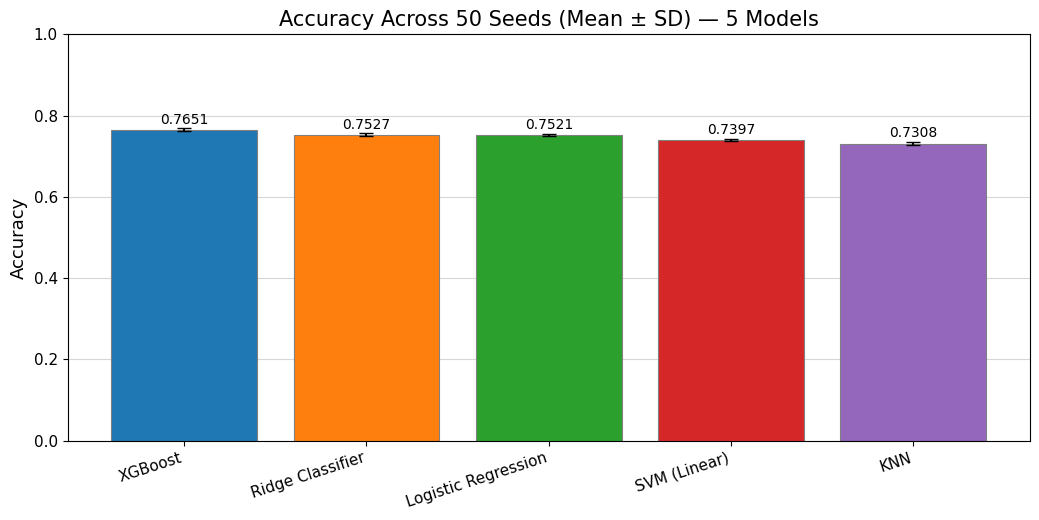

Saved to: C:\Users\niuni\Research\Alzheimer\run_AD08 20260227_205723 Ablasion AD08\tables\accuracy_bar_chart_5models_labeled.png


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ===== EDIT THIS PATH =====
csv_path = Path(r"C:\Users\niuni\Research\Alzheimer\run_AD08 20260227_205723 Ablasion AD08\tables\accuracy_summary_mean_sd_5models.csv")
out_path = csv_path.parent / "accuracy_bar_chart_5models_labeled.png"
# ==========================

df = pd.read_csv(csv_path)

order = ["XGBoost", "Ridge Classifier", "Logistic Regression", "SVM (Linear)", "KNN"]
df["Model"] = pd.Categorical(df["Model"], categories=order, ordered=True)
df = df.sort_values("Model").reset_index(drop=True)

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

fig, ax = plt.subplots(figsize=(10.5, 5.3))

bars = ax.bar(
    df["Model"],
    df["mean_acc"],
    yerr=df["sd_acc"],
    capsize=5,
    color=colors,
    edgecolor="gray",
    linewidth=0.8
)

ax.set_title("Accuracy Across 50 Seeds (Mean ± SD) — 5 Models", fontsize=15)
ax.set_ylabel("Accuracy", fontsize=13)
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.5)
ax.set_axisbelow(True)
plt.xticks(rotation=18, ha="right", fontsize=11)
plt.yticks(fontsize=11)

for bar, val, err in zip(bars, df["mean_acc"], df["sd_acc"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + err + 0.004,
        f"{val:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {out_path}")

In [10]:
create a table under jupyter with description of all features included in the dataset used for Alzheimer’s disease diagnosis classification. The table lists each variable and a brief description of the clinical or demographic information represented.

SyntaxError: invalid character '’' (U+2019) (2412580919.py, line 1)